<a href="https://colab.research.google.com/github/govhersalmanova/data-analysis-notebook/blob/main/Govhar_Salmanova_Automobile_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automobile Dataset Analysis

**Project theme:** Exploring car features and fuel efficiency.

**Main target variable:** `mpg`

**Dataset columns:** `name`, `mpg`, `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `model_year`, `origin`

**AZ:** Bu notebook avtomobil cədvəlinə əsasən analiz üçün hazırlanıb. Başlıqlar və suallar hazırdır. Hər sualın altında kod yazmaq üçün cell saxlanılıb.

## 1. Import Required Libraries

**Task:** Import the necessary Python libraries for data analysis and visualization.

**AZ:** Data analizi və qrafiklər üçün lazım olan kitabxanaları import et.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



## 2. Load the Dataset

**Task:** Load the automobile dataset into a pandas DataFrame.

**Question:** How can we read the Excel or CSV file into Python?

**AZ:** Avtomobil datasetini pandas DataFrame kimi yüklə.

In [ ]:
# Load the dataset
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

if filename.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(filename)
elif filename.lower().endswith(".csv"):
    df = pd.read_csv(filename)
else:
    raise ValueError("Please upload a CSV or Excel file.")

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Convert numerical columns to numeric format
numeric_cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Clean text values in origin column
if "origin" in df.columns:
    df["origin"] = df["origin"].astype(str).str.strip().str.lower()

df.head()


Saving Automobile.csv.xlsx to Automobile.csv (1).xlsx


,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,70,usa
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,70,usa
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,70,usa
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,70,usa
4,ford torino,17.0,8,302.0,140.0,3449,10.5,70,usa


## 3. Preview the Dataset

**Task:** Display the first and last rows of the dataset.

**Questions:**
- What does the dataset look like?
- What kind of information is included in the table?

**AZ:** Datasetin ilk və son sətirlərinə bax. Cədvəldə hansı məlumatların olduğunu başa düş.

In [ ]:
df.head()



,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,70,usa
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,70,usa
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,70,usa
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,70,usa
4,ford torino,17.0,8,302.0,140.0,3449,10.5,70,usa


In [ ]:
df.tail()

,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
393,ford mustang gl,27.0,4,140.0,86.0,2790,15.6,82,usa
394,vw pickup,44.0,4,97.0,52.0,2130,24.6,82,europe
395,dodge rampage,32.0,4,135.0,84.0,2295,11.6,82,usa
396,ford ranger,28.0,4,120.0,79.0,2625,18.6,82,usa
397,chevy s-10,31.0,4,119.0,82.0,2720,19.4,82,usa


## 4. Dataset Shape and Column Names

**Task:** Check the number of rows, number of columns, and column names.

**Questions:**
- How many rows and columns are in the dataset?
- What are the column names?

**AZ:** Datasetdə neçə sətir və sütun olduğunu, həmçinin sütun adlarını yoxla.

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Column names:")
print(df.columns.tolist())


Number of rows: 398
Number of columns: 9
Column names:
['name', 'mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']


## 5. Data Types

**Task:** Check the data types of all columns.

**Questions:**
- Which columns are numerical?
- Which columns are categorical/text-based?
- Are all numerical columns stored correctly?

**AZ:** Hər sütunun data tipini yoxla. Rəqəmsal sütunlar doğrudan da rəqəm kimi oxunubmu?

In [ ]:
print(df.dtypes)




name             object
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
dtype: object


In [ ]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          398 non-null    object 
 1   mpg           398 non-null    float64
 2   cylinders     398 non-null    int64  
 3   displacement  398 non-null    float64
 4   horsepower    392 non-null    float64
 5   weight        398 non-null    int64  
 6   acceleration  398 non-null    float64
 7   model_year    398 non-null    int64  
 8   origin        398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


## 6. Missing Values

**Task:** Check whether the dataset contains missing values.

**Questions:**
- Are there any missing values in the dataset?
- Which columns have missing values?
- Should missing rows be removed or corrected?

**AZ:** Datasetdə boş xanalar olub-olmadığını yoxla.

In [ ]:
missing_values = df.isnull().sum()
missing_values


,0
name,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0


## 7. Duplicated Rows

**Task:** Check whether the dataset contains duplicated rows.

**Questions:**
- Are there any duplicated rows?
- Should duplicated rows be removed?

**AZ:** Təkrarlanan sətirlər olub-olmadığını yoxla.

In [ ]:
uplicated_rows = df.duplicated().sum()
print("Number of duplicated rows:", duplicated_rows)


Number of duplicated rows: 0


## 8. Descriptive Statistics

**Task:** Generate descriptive statistics for numerical columns.

**Questions:**
- What is the average MPG?
- What are the minimum and maximum values for horsepower, weight, and acceleration?
- Which variables have the widest range?

**AZ:** Rəqəmsal sütunların statistik xülasəsini çıxart: orta, minimum, maksimum və s.

In [ ]:
df.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## 9. Distribution of MPG

**Task:** Visualize the distribution of `mpg`.

**Questions:**
- How is MPG distributed among the cars?
- Are most cars low MPG, medium MPG, or high MPG?

**AZ:** `mpg` sütununun paylanmasını qrafiklə göstər. Maşınların yanacaq səmərəliliyi necə yayılıb?

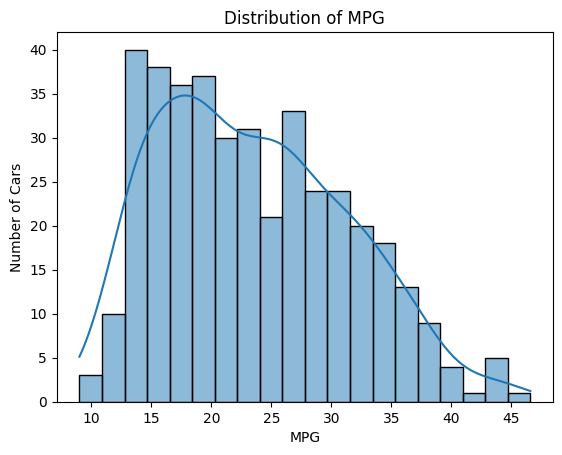

In [ ]:
sns.histplot(data=df, x="mpg", bins=20, kde=True)
plt.title("Distribution of MPG")
plt.xlabel("MPG")
plt.ylabel("Number of Cars")
plt.show()


## 10. Cars by Origin

**Task:** Count and visualize how many cars come from each origin.

**Questions:**
- Which origin has the highest number of cars?
- Which origin has the lowest number of cars?

**AZ:** Hər `origin` üzrə neçə maşın olduğunu tap və qrafiklə göstər.

,count
origin,
usa,249
japan,79
europe,70


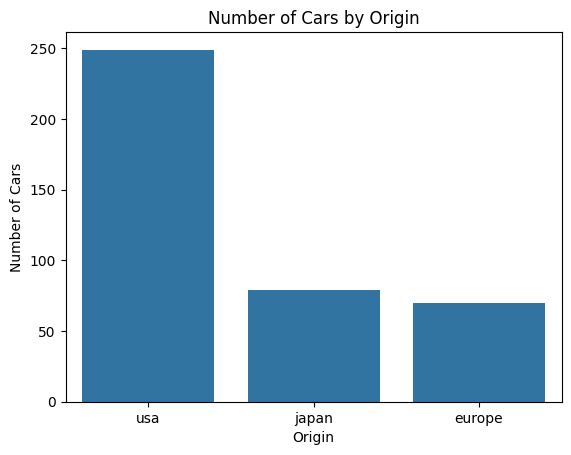

In [ ]:
origin_counts = df["origin"].value_counts()
display(origin_counts)

sns.countplot(data=df, x="origin", order=origin_counts.index)
plt.title("Number of Cars by Origin")
plt.xlabel("Origin")
plt.ylabel("Number of Cars")
plt.show()


## 11. Cars by Number of Cylinders

**Task:** Analyze the number of cars in each cylinder group.

**Questions:**
- Which cylinder category is the most common?
- Are there more 4-cylinder cars or 8-cylinder cars?

**AZ:** Silindr sayına görə maşınların bölgüsünü analiz et.

,count
cylinders,
3,4
4,204
5,3
6,84
8,103


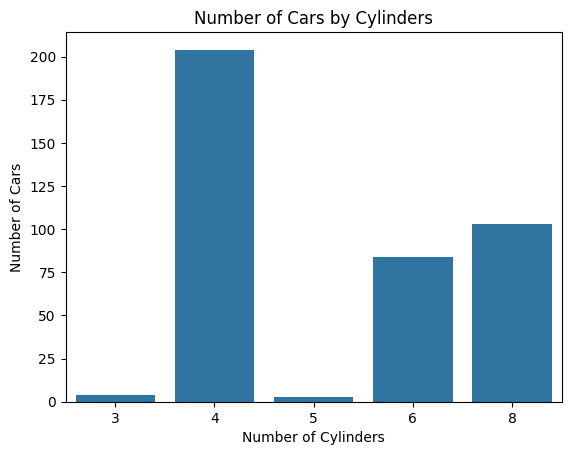

In [ ]:
cylinder_counts = df["cylinders"].value_counts().sort_index()
display(cylinder_counts)

sns.countplot(data=df, x="cylinders", order=sorted(df["cylinders"].dropna().unique()))
plt.title("Number of Cars by Cylinders")
plt.xlabel("Number of Cylinders")
plt.ylabel("Number of Cars")
plt.show()


## 12. Average MPG by Origin

**Task:** Compare the average MPG for each origin.

**Questions:**
- Which origin has the highest average MPG?
- Which origin has the lowest average MPG?
- Do cars from different origins have different fuel efficiency?

**AZ:** Müxtəlif origin-lərə görə orta MPG-ni müqayisə et.

,mpg
origin,
japan,30.450633
europe,27.891429
usa,20.083534


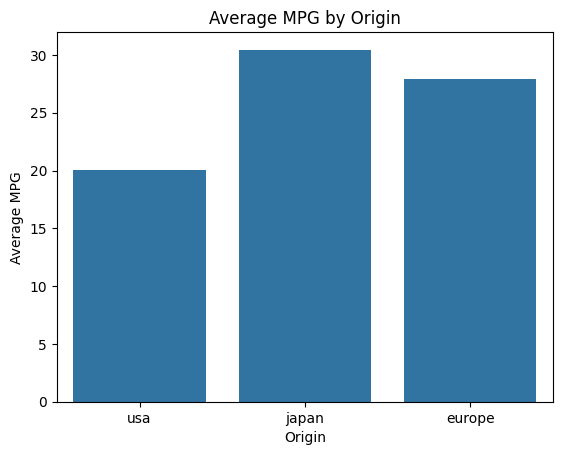

In [ ]:
avg_mpg_origin = df.groupby("origin")["mpg"].mean().sort_values(ascending=False)
display(avg_mpg_origin)

sns.barplot(data=df, x="origin", y="mpg", estimator="mean", errorbar=None)
plt.title("Average MPG by Origin")
plt.xlabel("Origin")
plt.ylabel("Average MPG")
plt.show()


## 13. MPG by Cylinders

**Task:** Analyze the relationship between the number of cylinders and MPG.

**Questions:**
- Do cars with fewer cylinders have higher MPG?
- Do cars with more cylinders have lower MPG?
- Which cylinder group is the most fuel efficient?

**AZ:** Silindr sayı ilə yanacaq səmərəliliyi arasında əlaqəni analiz et.

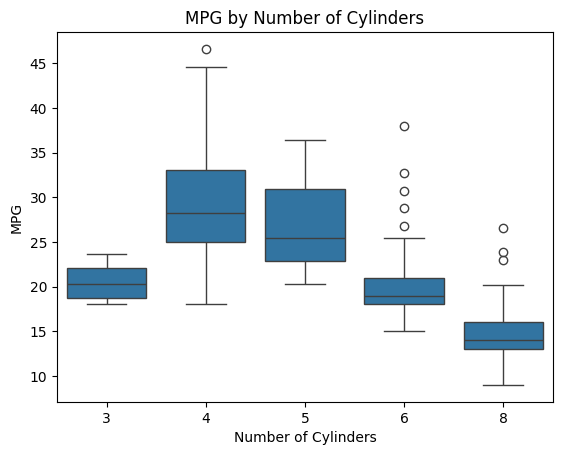

,mpg
cylinders,
3,20.550000
4,29.286765
5,27.366667
6,19.985714
8,14.963107


In [ ]:
sns.boxplot(data=df, x="cylinders", y="mpg")
plt.title("MPG by Number of Cylinders")
plt.xlabel("Number of Cylinders")
plt.ylabel("MPG")
plt.show()

avg_mpg_cylinders = df.groupby("cylinders")["mpg"].mean().sort_index()
display(avg_mpg_cylinders)


## 14. Weight vs MPG

**Task:** Analyze whether car weight affects MPG.

**Questions:**
- Is there a relationship between weight and MPG?
- Do heavier cars usually have lower MPG?
- Is the relationship positive or negative?

**AZ:** Maşının çəkisi artdıqca MPG azalırmı? Bunu qrafiklə göstər.

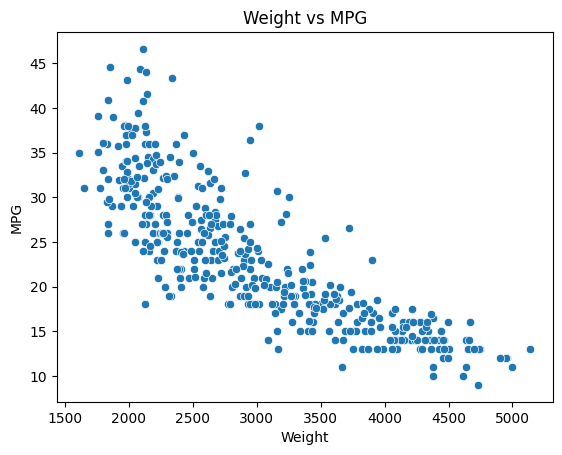

Correlation between weight and MPG: -0.8317409332443352


In [ ]:
sns.scatterplot(data=df, x="weight", y="mpg")
plt.title("Weight vs MPG")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.show()

weight_mpg_corr = df["weight"].corr(df["mpg"])
print("Correlation between weight and MPG:", weight_mpg_corr)


## 15. Horsepower vs MPG

**Task:** Analyze whether horsepower affects MPG.

**Questions:**
- Is there a relationship between horsepower and MPG?
- Do cars with higher horsepower usually have lower MPG?
- Is the relationship strong or weak?

**AZ:** Horsepower ilə MPG arasında əlaqəni analiz et.

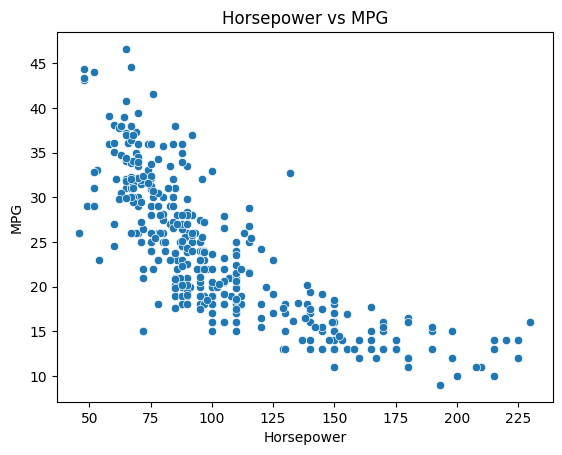

Correlation between horsepower and MPG: -0.7784267838977756


In [ ]:
sns.scatterplot(data=df, x="horsepower", y="mpg")
plt.title("Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()

horsepower_mpg_corr = df["horsepower"].corr(df["mpg"])
print("Correlation between horsepower and MPG:", horsepower_mpg_corr)


## 16. Model Year vs MPG

**Task:** Analyze whether fuel efficiency improved over the years.

**Questions:**
- Did average MPG increase over model years?
- Are newer cars more fuel efficient than older cars?
- What trend can be observed?

**AZ:** Model ili artdıqca maşınların yanacaq səmərəliliyi yaxşılaşıbmı?

In [ ]:
avg_mpg_year = df.groupby("model_year")["mpg"].mean().reset_index()
display(avg_mpg_year)




,model_year,mpg
0,70,17.689655
1,71,21.250000
2,72,18.714286
3,73,17.100000
4,74,22.703704
5,75,20.266667
6,76,21.573529
7,77,23.375000
8,78,24.061111
9,79,25.093103


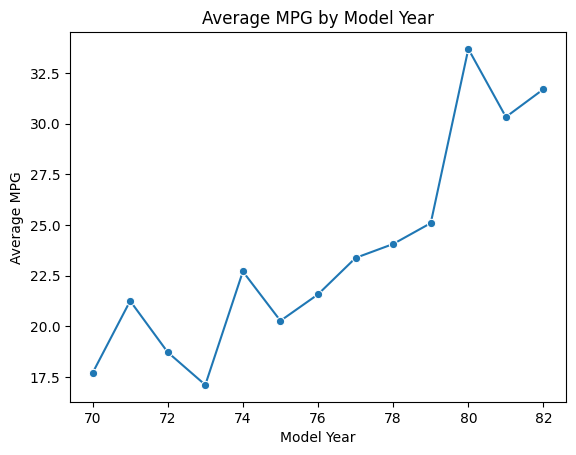

In [ ]:
sns.lineplot(data=avg_mpg_year, x="model_year", y="mpg", marker="o")
plt.title("Average MPG by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.show()

## 17. Correlation Analysis

**Task:** Create a correlation matrix for numerical variables.

**Questions:**
- Which variable has the strongest negative correlation with MPG?
- Which variable has the strongest positive correlation with MPG?
- Are weight, horsepower, displacement, and cylinders strongly related to MPG?

**AZ:** Rəqəmsal dəyişənlər arasında correlation matrix qur və MPG ilə ən güclü əlaqədə olan faktorları tap.

In [ ]:
numeric_df = df.select_dtypes(include=["number"])
corr = numeric_df.corr()

display(corr)




,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419,-0.348746
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684,-0.370164
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137
model_year,0.579267,-0.348746,-0.370164,-0.416361,-0.306564,0.288137,1.000000


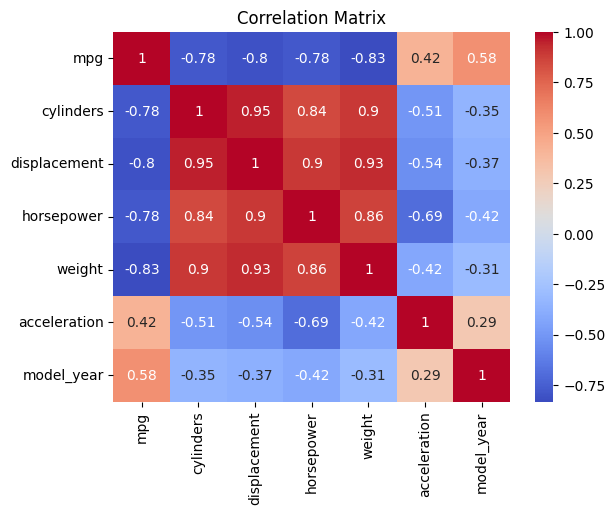

In [ ]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()



In [ ]:
mpg_correlations = corr["mpg"].sort_values(ascending=False)
display(mpg_correlations)

,mpg
mpg,1.000000
model_year,0.579267
acceleration,0.420289
cylinders,-0.775396
horsepower,-0.778427
displacement,-0.804203
weight,-0.831741


## 18. Final Findings

**Task:** Summarize the main findings of the analysis.

**Questions:**
- What are the main factors affecting MPG?
- Do heavier and more powerful cars have lower MPG?
- Did fuel efficiency improve over time?
- What is the overall conclusion of the analysis?

**AZ:** Analizin əsas nəticələrini qısa formada yaz.

### Final Conclusion Template

You can complete this paragraph after finishing your analysis:

> In this project, I analyzed an automobile dataset to understand the factors affecting fuel efficiency. The main target variable was MPG. The analysis showed that __________. Cars with higher __________ usually had lower MPG. The results also showed that __________. Overall, the most important factors affecting MPG were __________.

**AZ:** Analizi bitirəndən sonra bu paragraph-ı öz nəticələrinə uyğun tamamla.

In [ ]:
# Automatic summary of main findings
best_origin = df.groupby("origin")["mpg"].mean().idxmax()
lowest_origin = df.groupby("origin")["mpg"].mean().idxmin()
best_cylinder_group = df.groupby("cylinders")["mpg"].mean().idxmax()
lowest_cylinder_group = df.groupby("cylinders")["mpg"].mean().idxmin()

corr_with_mpg = df.select_dtypes(include=["number"]).corr()["mpg"].drop("mpg")
strongest_negative = corr_with_mpg.idxmin()
strongest_positive = corr_with_mpg.idxmax()

print("Final Findings")
print("--------------")
print(f"Average MPG: {df['mpg'].mean():.2f}")
print(f"Origin with the highest average MPG: {best_origin}")
print(f"Origin with the lowest average MPG: {lowest_origin}")
print(f"Cylinder group with the highest average MPG: {best_cylinder_group}")
print(f"Cylinder group with the lowest average MPG: {lowest_cylinder_group}")
print(f"Strongest negative correlation with MPG: {strongest_negative}")
print(f"Strongest positive correlation with MPG: {strongest_positive}")

print("\nConclusion:")
print("The analysis shows that MPG is strongly affected by car features such as weight, horsepower, cylinders, displacement, model year, and origin.")
print("Heavier and more powerful cars usually have lower MPG, while newer cars and cars with fewer cylinders usually have better fuel efficiency.")


Final Findings
--------------
Average MPG: 23.51
Origin with the highest average MPG: japan
Origin with the lowest average MPG: usa
Cylinder group with the highest average MPG: 4
Cylinder group with the lowest average MPG: 8
Strongest negative correlation with MPG: weight
Strongest positive correlation with MPG: model_year

Conclusion:
The analysis shows that MPG is strongly affected by car features such as weight, horsepower, cylinders, displacement, model year, and origin.
Heavier and more powerful cars usually have lower MPG, while newer cars and cars with fewer cylinders usually have better fuel efficiency.
